# IN718 Sample Comparison: Basic vs Symmetry-Aware vs Boundary-Aware SLERP

Pipeline uses:
- `slerp_final.py`
- `segment_grains.py`

Methods are tested on the sample selected in the next code cell (`split` + `sample_idx`).
1. Basic SLERP (no symmetry)
2. Symmetry-aware SLERP (`SymBilinearSlerpUpsample`)
3. Boundary-aware symmetry SLERP (label/SDF guided)


In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from orix.quaternion import symmetry as SYM

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "training").exists():
    REPO_ROOT = REPO_ROOT.parent

NB_DIR = REPO_ROOT / "notebooks"
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
if str(NB_DIR) not in sys.path:
    sys.path.insert(0, str(NB_DIR))

from training.quaternion_dataset import QuaternionDataset
from visualization.ipf_render import render_ipf_image, render_ipf_rgb

from slerp_final import (
    SymBilinearSlerpUpsample,
    bilinear_slerp_sym,
    make_fcc_symmetry_4x4,
    qnorm,
    slerp,
    symmetrize_pair,
)
from segment_grains import (
    build_sdf,
    build_smooth_hr_labels,
    cleanup_small_grains_cuda,
    segment_grains_graph,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


In [2]:
dataset_dir = Path("/data/home/umang/Materials/Materials_data_mount/datasets/IN718")
#hr_gt_file= "/data/home/umang/Materials/Materials_data_mount/datasets//Train/HR_Data/IN718_QSR_4x1_train_hr_x_block_338.npy"
#lr_file= "/data/home/umang/Materials/Materials_data_mount/datasets//Train/LR_Data/IN718_QSR_4x1_train_lr_x_block_338.npy"
sample_idx = 225
split = "Train"
scale = 4
out_dir = REPO_ROOT / "outputs" / f"in718_{split.lower()}_sample{sample_idx}_slerp_final_segment_grains"
out_dir.mkdir(parents=True, exist_ok=True)

ds = QuaternionDataset(dataset_root=str(dataset_dir), split=split)
n_samples = len(ds)
if not (0 <= sample_idx < n_samples):
    raise IndexError(
        f"sample_idx={sample_idx} is out of range for split='{split}' "
        f"(valid range: 0..{n_samples - 1})."
    )

q_lr_sample, q_hr_sample = ds[sample_idx]

def to_chw_quat(q: torch.Tensor, name: str) -> torch.Tensor:
    if q.ndim != 3:
        raise ValueError(f"{name} must have 3 dims, got shape {tuple(q.shape)}")
    if q.shape[0] == 4:
        return q.contiguous()
    if q.shape[-1] == 4:
        return q.permute(2, 0, 1).contiguous()
    raise ValueError(f"{name} must have quaternion dimension of size 4, got shape {tuple(q.shape)}")

q_lr_sample = to_chw_quat(q_lr_sample, "LR sample")
q_hr_sample = to_chw_quat(q_hr_sample, "HR sample")
q_lr = q_lr_sample.unsqueeze(0).to(device=device, dtype=torch.float32)
q_hr_gt = q_hr_sample.unsqueeze(0).to(device=device, dtype=torch.float32)
q_lr = qnorm(q_lr)
q_hr_gt = qnorm(q_hr_gt)

sym_np_path = REPO_ROOT / "symmetry_groups" / "O_group.npy"
if sym_np_path.exists():
    sym_ops = torch.tensor(np.load(sym_np_path), dtype=q_lr.dtype, device=device)
else:
    sym_ops = make_fcc_symmetry_4x4(device=device, dtype=q_lr.dtype)

sym_class = SYM.O
print("dataset split:", split)
print("num samples:", n_samples)
print("q_lr shape:", tuple(q_lr.shape))
print("q_hr_gt shape:", tuple(q_hr_gt.shape))
print("sym_ops shape:", tuple(sym_ops.shape))
print("out_dir:", out_dir)


dataset split: Train
num samples: 1174
q_lr shape: (1, 4, 32, 32)
q_hr_gt shape: (1, 4, 128, 128)
sym_ops shape: (24, 4, 4)
out_dir: /data/home/umang/Materials/Reynolds-QSR_4x1/outputs/in718_train_sample225_slerp_final_segment_grains


In [3]:
class BasicBilinearSlerpUpsample(nn.Module):
    """Basic bilinear SLERP upsampler without symmetry handling."""

    def __init__(self, scale_factor: int):
        super().__init__()
        self.scale = int(scale_factor)

    @torch.no_grad()
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, C, H, W = x.shape
        assert C == 4
        s = self.scale
        x = qnorm(x)

        H_out, W_out = H * s, W * s
        device, dtype = x.device, x.dtype

        iy = torch.arange(H_out, device=device, dtype=dtype)
        ix = torch.arange(W_out, device=device, dtype=dtype)
        y = (iy + 0.5) / s - 0.5
        xcoord = (ix + 0.5) / s - 0.5

        y0 = torch.floor(y).clamp(0, H - 1).long()
        x0 = torch.floor(xcoord).clamp(0, W - 1).long()
        y1 = (y0 + 1).clamp(0, H - 1)
        x1 = (x0 + 1).clamp(0, W - 1)

        v = (y - y0.to(dtype)).clamp(0.0, 1.0)
        u = (xcoord - x0.to(dtype)).clamp(0.0, 1.0)
        v_grid, u_grid = torch.meshgrid(v, u, indexing="ij")

        y0g = y0.view(H_out, 1).expand(H_out, W_out)
        y1g = y1.view(H_out, 1).expand(H_out, W_out)
        x0g = x0.view(1, W_out).expand(H_out, W_out)
        x1g = x1.view(1, W_out).expand(H_out, W_out)

        q00 = x[:, :, y0g, x0g]
        q01 = x[:, :, y0g, x1g]
        q10 = x[:, :, y1g, x0g]
        q11 = x[:, :, y1g, x1g]

        def flat(q: torch.Tensor) -> torch.Tensor:
            return q.permute(0, 2, 3, 1).reshape(-1, 4)

        q00_f = flat(q00)
        q01_f = flat(q01)
        q10_f = flat(q10)
        q11_f = flat(q11)

        u_full = u_grid.unsqueeze(0).expand(B, -1, -1).reshape(-1)
        v_full = v_grid.unsqueeze(0).expand(B, -1, -1).reshape(-1)

        q0u = slerp(q00_f, q01_f, u_full)
        q1u = slerp(q10_f, q11_f, u_full)
        q_uv = slerp(q0u, q1u, v_full)

        out = q_uv.view(B, H_out, W_out, 4).permute(0, 3, 1, 2).contiguous()
        return qnorm(out)


def plot_lr_hr_labels_panels_with_sdf(
    labels_lr,
    labels_hr,
    sdf_hr,
    out_png,
    lr_zoom=(slice(20, 35), slice(None)),
    hr_zoom1=(slice(65, 125), slice(None)),
    hr_zoom2=(slice(110, 125), slice(70, 85)),
):
    lr_np = labels_lr.detach().cpu().numpy()
    hr_np = labels_hr.detach().cpu().numpy()
    sdf_np = sdf_hr.detach().cpu().numpy()

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    ax = axes.flatten()

    ax[0].imshow(lr_np, cmap="tab20")
    ax[0].set_title("LR Labels")
    ax[0].axis("off")

    ax[1].imshow(lr_np[lr_zoom], cmap="tab20")
    ax[1].set_title(f"LR Zoom {lr_zoom}")
    ax[1].axis("off")

    ax[2].imshow(hr_np, cmap="tab20")
    ax[2].set_title("HR Smooth Labels")
    ax[2].axis("off")

    ax[3].imshow(hr_np[hr_zoom1], cmap="tab20")
    ax[3].set_title(f"HR Zoom 1 {hr_zoom1}")
    ax[3].axis("off")

    ax[4].imshow(hr_np[hr_zoom2], cmap="tab20")
    ax[4].set_title(f"HR Zoom 2 {hr_zoom2}")
    ax[4].axis("off")

    im = ax[5].imshow(sdf_np, cmap="viridis")
    ax[5].set_title("HR SDF (Smoothed Boundary Field)")
    ax[5].axis("off")
    fig.colorbar(im, ax=ax[5], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.savefig(out_png, dpi=200)
    plt.close()
    print(f"Saved label/SDF panel -> {out_png}")


@torch.no_grad()
def analyze_boundary_cases(
    labels_lr: torch.Tensor,
    labels_hr: torch.Tensor,
    scale: int,
    out_png: str | None = None,
):
    device = labels_lr.device
    scale = int(scale)

    H_lr, W_lr = labels_lr.shape
    H_hr, W_hr = labels_hr.shape
    assert H_hr == H_lr * scale and W_hr == W_lr * scale

    yy_hr = torch.arange(H_hr, device=device, dtype=torch.float32)
    xx_hr = torch.arange(W_hr, device=device, dtype=torch.float32)
    y_hr, x_hr = torch.meshgrid(yy_hr, xx_hr, indexing="ij")

    y_lr_f = (y_hr + 0.5) / scale - 0.5
    x_lr_f = (x_hr + 0.5) / scale - 0.5

    y0 = torch.floor(y_lr_f).long().clamp(0, H_lr - 1)
    x0 = torch.floor(x_lr_f).long().clamp(0, W_lr - 1)
    y1 = (y0 + 1).clamp(0, H_lr - 1)
    x1 = (x0 + 1).clamp(0, W_lr - 1)

    ty = (y_lr_f - y0.float()).clamp(0.0, 1.0)
    tx = (x_lr_f - x0.float()).clamp(0.0, 1.0)

    w00 = (1.0 - tx) * (1.0 - ty)
    w01 = tx * (1.0 - ty)
    w10 = (1.0 - tx) * ty
    w11 = tx * ty

    g00 = labels_lr[y0, x0]
    g01 = labels_lr[y0, x1]
    g10 = labels_lr[y1, x0]
    g11 = labels_lr[y1, x1]

    g_neighbors = torch.stack((g00, g01, g10, g11), dim=-1)
    w_neighbors = torch.stack((w00, w01, w10, w11), dim=-1)
    same_mask = g_neighbors == labels_hr.unsqueeze(-1)

    N = H_hr * W_hr
    same_mask_flat = same_mask.reshape(N, 4)
    w_flat = w_neighbors.reshape(N, 4)

    num_valid = same_mask_flat.sum(dim=1)
    case_map_flat = torch.zeros(N, dtype=torch.uint8, device=device)
    case_map_flat[num_valid == 4] = 3
    case_map_flat[(num_valid >= 2) & (num_valid < 4)] = 2
    case_map_flat[num_valid == 1] = 1
    case_map = case_map_flat.view(H_hr, W_hr)

    if out_png is not None:
        case_np = case_map.detach().cpu().numpy()
        fig, ax = plt.subplots(1, 1, figsize=(6, 6))
        im = ax.imshow(case_np, cmap="tab10", vmin=0, vmax=3)
        ax.set_title("Boundary Case Map: 0 none, 1 single, 2 multi, 3 interior")
        ax.axis("off")
        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_ticks([0, 1, 2, 3])
        plt.tight_layout()
        plt.savefig(out_png, dpi=200)
        plt.close()
        print(f"Saved boundary case map -> {out_png}")

    return same_mask_flat, w_flat, case_map


@torch.no_grad()
def boundary_aware_sym_slerp_upsample(
    q_lr: torch.Tensor,
    labels_lr: torch.Tensor,
    labels_hr: torch.Tensor,
    sym_ops: torch.Tensor,
    scale: int,
    same_mask_flat: torch.Tensor,
    w_flat: torch.Tensor,
    case_map: torch.Tensor,
) -> torch.Tensor:
    device = q_lr.device
    dtype = q_lr.dtype
    scale = int(scale)

    B, C, H_lr, W_lr = q_lr.shape
    assert B == 1 and C == 4
    H_hr, W_hr = labels_hr.shape
    assert H_hr == H_lr * scale and W_hr == W_lr * scale

    yy_hr = torch.arange(H_hr, device=device, dtype=torch.float32)
    xx_hr = torch.arange(W_hr, device=device, dtype=torch.float32)
    y_hr, x_hr = torch.meshgrid(yy_hr, xx_hr, indexing="ij")

    y_lr_f = (y_hr + 0.5) / scale - 0.5
    x_lr_f = (x_hr + 0.5) / scale - 0.5

    y0 = torch.floor(y_lr_f).long().clamp(0, H_lr - 1)
    x0 = torch.floor(x_lr_f).long().clamp(0, W_lr - 1)
    y1 = (y0 + 1).clamp(0, H_lr - 1)
    x1 = (x0 + 1).clamp(0, W_lr - 1)

    ty = (y_lr_f - y0.float()).clamp(0.0, 1.0)
    tx = (x_lr_f - x0.float()).clamp(0.0, 1.0)
    u_flat = tx.reshape(-1)
    v_flat = ty.reshape(-1)

    q_lr_hw = q_lr.squeeze(0).permute(1, 2, 0).contiguous()
    q00 = q_lr_hw[y0, x0]
    q01 = q_lr_hw[y0, x1]
    q10 = q_lr_hw[y1, x0]
    q11 = q_lr_hw[y1, x1]

    N = H_hr * W_hr
    q00_flat = q00.reshape(N, 4)
    q01_flat = q01.reshape(N, 4)
    q10_flat = q10.reshape(N, 4)
    q11_flat = q11.reshape(N, 4)

    q_neighbors_flat = torch.stack((q00_flat, q01_flat, q10_flat, q11_flat), dim=1)
    case_flat = case_map.reshape(-1)
    gid_hr_flat = labels_hr.reshape(-1)
    y_lr_f_flat = y_lr_f.reshape(-1)
    x_lr_f_flat = x_lr_f.reshape(-1)

    q_out_flat = torch.zeros((N, 4), dtype=dtype, device=device)

    mask3 = case_flat == 3
    idx3 = torch.nonzero(mask3, as_tuple=False).squeeze(1)
    if idx3.numel() > 0:
        q_uv_3 = bilinear_slerp_sym(
            q00_flat[idx3],
            q01_flat[idx3],
            q10_flat[idx3],
            q11_flat[idx3],
            u_flat[idx3],
            v_flat[idx3],
            sym_ops,
        )
        q_out_flat[idx3] = q_uv_3

    mask1 = case_flat == 1
    idx1 = torch.nonzero(mask1, as_tuple=False).squeeze(1)
    if idx1.numel() > 0:
        same1 = same_mask_flat[idx1]
        pos1 = same1.long().argmax(dim=1)
        q_nb1 = q_neighbors_flat[idx1]
        b_idx = torch.arange(idx1.numel(), device=device)
        q_out_flat[idx1] = q_nb1[b_idx, pos1]

    mask2 = case_flat == 2
    idx2 = torch.nonzero(mask2, as_tuple=False).squeeze(1)
    if idx2.numel() > 0:
        q_nb2 = q_neighbors_flat[idx2]
        w2 = w_flat[idx2]
        same2 = same_mask_flat[idx2]
        N2 = idx2.numel()

        for i in range(N2):
            q_corners = q_nb2[i]
            m = same2[i]
            w = w2[i].clone()

            valid_idx = torch.nonzero(m, as_tuple=False).squeeze(1)
            K = valid_idx.numel()
            if K == 0:
                continue

            qv = q_corners[valid_idx]
            wv = w[valid_idx]
            wv = wv / (wv.sum() + 1e-12)

            q_ref = qv[0:1]
            total_w = wv[0].clone()
            for k in range(1, K):
                wk = wv[k]
                alpha = wk / (total_w + wk + 1e-12)
                q_ref_aligned, q_next = symmetrize_pair(q_ref, qv[k : k + 1], sym_ops)
                q_ref = slerp(
                    q_ref_aligned,
                    q_next,
                    torch.tensor([alpha], device=device, dtype=dtype),
                )
                total_w = total_w + wk

            q_out_flat[idx2[i]] = q_ref[0]

    mask0 = case_flat == 0
    idx0 = torch.nonzero(mask0, as_tuple=False).squeeze(1)
    if idx0.numel() > 0:
        labels_lr_cpu = labels_lr.detach().cpu()
        q_lr_hw_cpu = q_lr_hw.detach().cpu()
        max_r = 3

        for j in idx0.tolist():
            gid = int(gid_hr_flat[j].item())
            y_est = int(round(float(y_lr_f_flat[j].item())))
            x_est = int(round(float(x_lr_f_flat[j].item())))

            best_q = None
            found = False
            for r in range(1, max_r + 1):
                for dy in range(-r, r + 1):
                    for dx in range(-r, r + 1):
                        yy = min(max(y_est + dy, 0), H_lr - 1)
                        xx = min(max(x_est + dx, 0), W_lr - 1)
                        if int(labels_lr_cpu[yy, xx].item()) == gid:
                            best_q = q_lr_hw_cpu[yy, xx]
                            found = True
                            break
                    if found:
                        break
                if found:
                    break

            if best_q is None:
                yy = min(max(y_est, 0), H_lr - 1)
                xx = min(max(x_est, 0), W_lr - 1)
                best_q = q_lr_hw_cpu[yy, xx]

            q_out_flat[j] = qnorm(best_q.to(device=device, dtype=dtype).unsqueeze(0))[0]

    q_hr = q_out_flat.view(H_hr, W_hr, 4).permute(2, 0, 1).unsqueeze(0).contiguous()
    return qnorm(q_hr)


In [4]:
# Segment grains from sample 0 and build smooth HR labels/SDF
labels_np, n_grains = segment_grains_graph(q_lr.cpu(), sym_ops.cpu(), thr_deg=3.0)
labels_lr = torch.from_numpy(labels_np).long().to(device)
labels_lr = cleanup_small_grains_cuda(
    labels_lr,
    q_lr,
    sym_ops,
    min_pixels=3,
    max_iter=1,
)

labels_hr = build_smooth_hr_labels(labels_lr, scale=scale, sdf_shift=0.7)
sdf_hr = build_sdf(labels_lr, scale=scale)

same_mask_flat, w_flat, case_map = analyze_boundary_cases(
    labels_lr,
    labels_hr,
    scale=scale,
    out_png=str(out_dir / "boundary_case_map.png"),
)

plot_lr_hr_labels_panels_with_sdf(
    labels_lr,
    labels_hr,
    sdf_hr,
    out_png=str(out_dir / "lr_hr_sdf_overview.png"),
)

print("grains (initial graph):", n_grains)


Saved boundary case map -> /data/home/umang/Materials/Reynolds-QSR_4x1/outputs/in718_train_sample225_slerp_final_segment_grains/boundary_case_map.png
Saved label/SDF panel -> /data/home/umang/Materials/Reynolds-QSR_4x1/outputs/in718_train_sample225_slerp_final_segment_grains/lr_hr_sdf_overview.png
grains (initial graph): 38


In [5]:
# Run the three upsampling variants
basic_up = BasicBilinearSlerpUpsample(scale_factor=scale).to(device)
sym_up = SymBilinearSlerpUpsample(
    scale_factor=scale,
    seam_threshold_deg=5.0,
    device=str(device),
    dtype=q_lr.dtype,
).to(device)

with torch.inference_mode():
    q_hr_basic = basic_up(q_lr)
    q_hr_sym = sym_up(q_lr)

q_hr_boundary = boundary_aware_sym_slerp_upsample(
    q_lr=q_lr,
    labels_lr=labels_lr,
    labels_hr=labels_hr,
    sym_ops=sym_ops,
    scale=scale,
    same_mask_flat=same_mask_flat,
    w_flat=w_flat,
    case_map=case_map,
)

q_hr_basic = qnorm(q_hr_basic)
q_hr_sym = qnorm(q_hr_sym)
q_hr_boundary = qnorm(q_hr_boundary)

print("q_hr_basic:", tuple(q_hr_basic.shape))
print("q_hr_sym:", tuple(q_hr_sym.shape))
print("q_hr_boundary:", tuple(q_hr_boundary.shape))


[SymBilinearSlerpUpsample] seam crossings: 3720/32768 (11.353%)
q_hr_basic: (1, 4, 128, 128)
q_hr_sym: (1, 4, 128, 128)
q_hr_boundary: (1, 4, 128, 128)


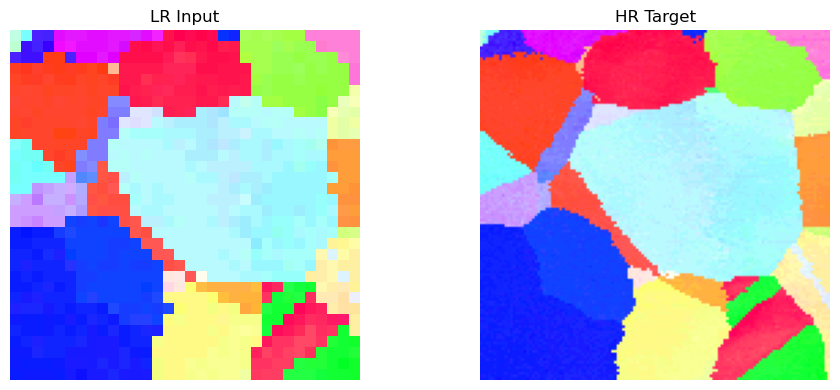

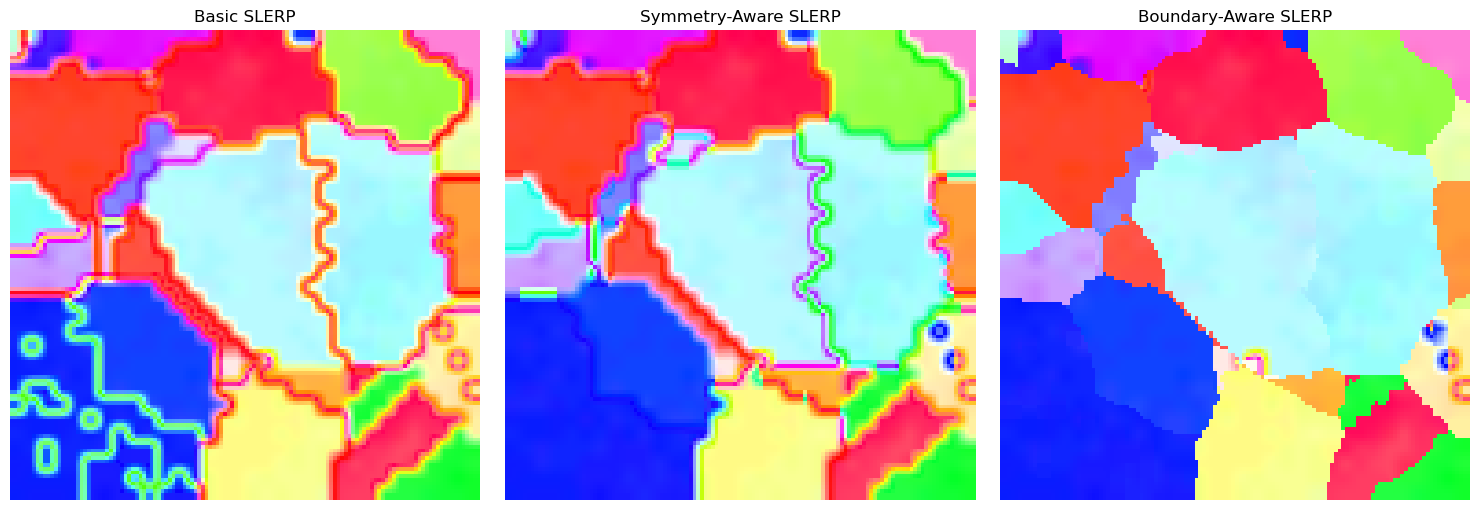

Saved outputs to: /data/home/umang/Materials/Reynolds-QSR_4x1/outputs/in718_train_sample225_slerp_final_segment_grains


In [6]:
def to_hwc_np(q: torch.Tensor) -> np.ndarray:
    return q.squeeze(0).permute(1, 2, 0).detach().cpu().numpy()

q_lr_np = to_hwc_np(q_lr)
q_hr_gt_np = to_hwc_np(q_hr_gt)
q_basic_np = to_hwc_np(q_hr_basic)
q_sym_np = to_hwc_np(q_hr_sym)
q_boundary_np = to_hwc_np(q_hr_boundary)

# Show LR and HR target first (before SR results)
rgb_lr = render_ipf_rgb(q_lr_np, sym_class, ref_dir="Z")
rgb_hr_gt = render_ipf_rgb(q_hr_gt_np, sym_class, ref_dir="Z")
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(rgb_lr); ax[0].set_title("LR Input") ; ax[0].axis("off")
ax[1].imshow(rgb_hr_gt); ax[1].set_title("HR Target") ; ax[1].axis("off")
plt.tight_layout()
plt.savefig(out_dir / "pre_slerp_lr_hr.png", dpi=200, bbox_inches="tight")
plt.show()

# Save standalone IPF images
render_ipf_image(q_lr_np, sym_class, out_png=str(out_dir / "ipf_lr.png"), ref_dir="Z", include_key=True, overwrite=True)
render_ipf_image(q_hr_gt_np, sym_class, out_png=str(out_dir / "ipf_hr_gt.png"), ref_dir="Z", include_key=True, overwrite=True)
render_ipf_image(q_basic_np, sym_class, out_png=str(out_dir / "ipf_hr_basic_slerp_x4.png"), ref_dir="Z", include_key=True, overwrite=True)
render_ipf_image(q_sym_np, sym_class, out_png=str(out_dir / "ipf_hr_symmetry_slerp_x4.png"), ref_dir="Z", include_key=True, overwrite=True)
render_ipf_image(q_boundary_np, sym_class, out_png=str(out_dir / "ipf_hr_boundary_slerp_x4.png"), ref_dir="Z", include_key=True, overwrite=True)

# Compare only SR maps side-by-side
rgb_basic = render_ipf_rgb(q_basic_np, sym_class, ref_dir="Z")
rgb_sym = render_ipf_rgb(q_sym_np, sym_class, ref_dir="Z")
rgb_boundary = render_ipf_rgb(q_boundary_np, sym_class, ref_dir="Z")

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(rgb_basic); ax[0].set_title("Basic SLERP") ; ax[0].axis("off")
ax[1].imshow(rgb_sym); ax[1].set_title("Symmetry-Aware SLERP") ; ax[1].axis("off")
ax[2].imshow(rgb_boundary); ax[2].set_title("Boundary-Aware SLERP") ; ax[2].axis("off")
plt.tight_layout()
plt.savefig(out_dir / "comparison_panel.png", dpi=200, bbox_inches="tight")
plt.show()

print("Saved outputs to:", out_dir)


In [7]:
# Extract grain-boundary masks from LR/HR label maps
def extract_boundary_mask(labels: torch.Tensor) -> torch.Tensor:
    if labels.ndim != 2:
        raise ValueError(f"Expected (H,W) labels, got shape {tuple(labels.shape)}")
    b = torch.zeros_like(labels, dtype=torch.bool)
    b[:, 1:] |= labels[:, 1:] != labels[:, :-1]
    b[1:, :] |= labels[1:, :] != labels[:-1, :]
    return b

boundary_lr = extract_boundary_mask(labels_lr)
boundary_hr = extract_boundary_mask(labels_hr)

# Only for visual comparison: project LR boundaries onto HR grid
boundary_lr_up = F.interpolate(
    boundary_lr.float().unsqueeze(0).unsqueeze(0),
    size=labels_hr.shape,
    mode="nearest",
)[0, 0].bool()

print("boundary_lr shape:", tuple(boundary_lr.shape), "pixels:", int(boundary_lr.sum().item()))
print("boundary_hr shape:", tuple(boundary_hr.shape), "pixels:", int(boundary_hr.sum().item()))


boundary_lr shape: (32, 32) pixels: 269
boundary_hr shape: (128, 128) pixels: 1145


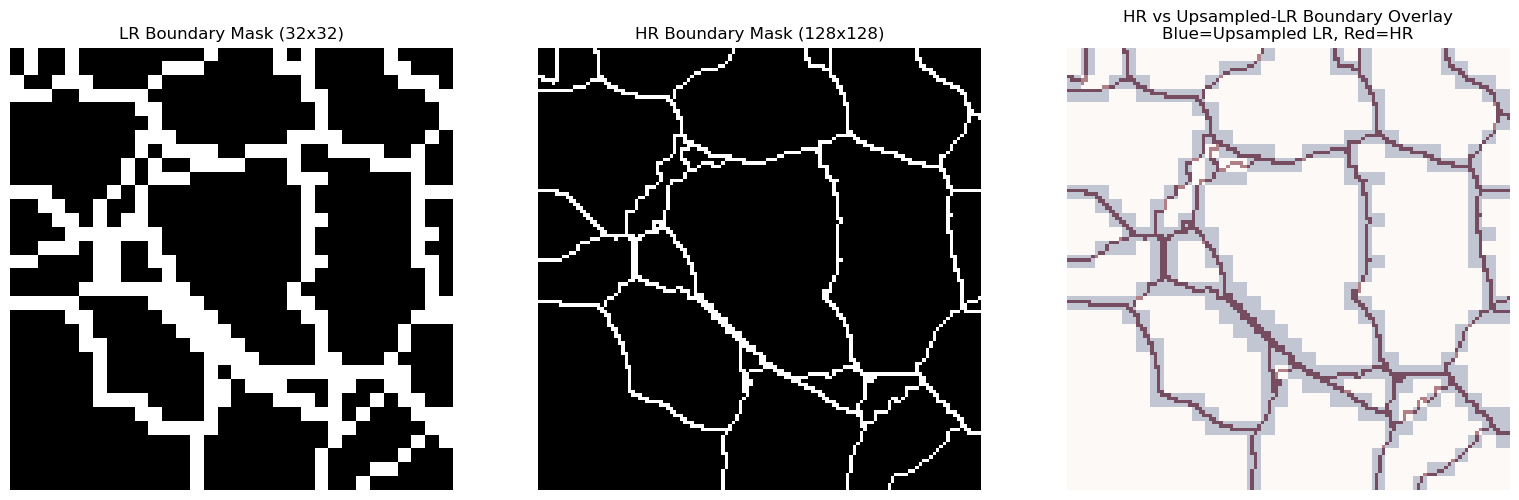

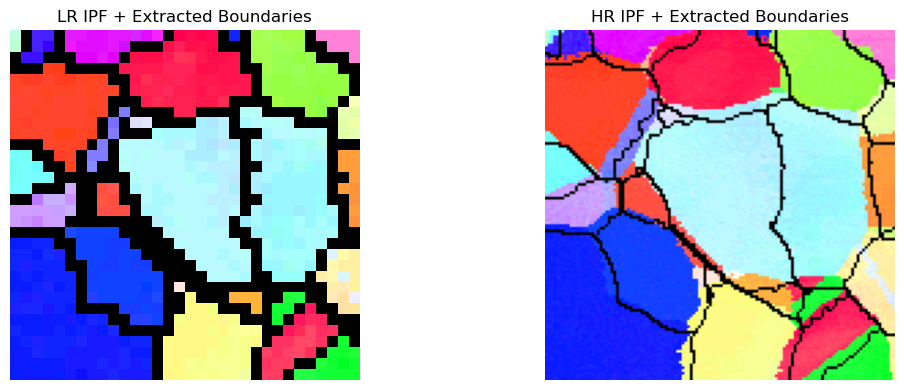

Saved: /data/home/umang/Materials/Reynolds-QSR_4x1/outputs/in718_train_sample225_slerp_final_segment_grains/boundary_masks_lr_hr.png
Saved: /data/home/umang/Materials/Reynolds-QSR_4x1/outputs/in718_train_sample225_slerp_final_segment_grains/boundary_overlay_lr_hr.png


In [8]:
# Plot extracted LR and HR boundaries
fig, ax = plt.subplots(1, 3, figsize=(16, 5))
ax[0].imshow(boundary_lr.detach().cpu().numpy(), cmap="gray")
ax[0].set_title(f"LR Boundary Mask ({boundary_lr.shape[0]}x{boundary_lr.shape[1]})")
ax[0].axis("off")

ax[1].imshow(boundary_hr.detach().cpu().numpy(), cmap="gray")
ax[1].set_title(f"HR Boundary Mask ({boundary_hr.shape[0]}x{boundary_hr.shape[1]})")
ax[1].axis("off")

ax[2].imshow(boundary_lr_up.detach().cpu().numpy(), cmap="Blues", alpha=0.5)
ax[2].imshow(boundary_hr.detach().cpu().numpy(), cmap="Reds", alpha=0.5)
ax[2].set_title("HR vs Upsampled-LR Boundary Overlay\nBlue=Upsampled LR, Red=HR")
ax[2].axis("off")

plt.tight_layout()
plt.savefig(out_dir / "boundary_masks_lr_hr.png", dpi=220, bbox_inches="tight")
plt.show()

# Optional: overlay boundaries on IPF for visual context
q_lr_np = to_hwc_np(q_lr)
q_hr_gt_np = to_hwc_np(q_hr_gt)
rgb_lr_local = render_ipf_rgb(q_lr_np, sym_class, ref_dir="Z").astype(np.float32)
rgb_hr_local = render_ipf_rgb(q_hr_gt_np, sym_class, ref_dir="Z").astype(np.float32)
if rgb_lr_local.max() > 1.0:
    rgb_lr_local /= 255.0
if rgb_hr_local.max() > 1.0:
    rgb_hr_local /= 255.0

rgb_lr_local[boundary_lr.detach().cpu().numpy()] = [0.0, 0.0, 0.0]
# For HR IPF target, show boundaries from labels_hr cropped to GT width if needed
bh = boundary_hr.detach().cpu().numpy()
bh_cropped = bh[:, : rgb_hr_local.shape[1]]
rgb_hr_local[bh_cropped] = [0.0, 0.0, 0.0]

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].imshow(rgb_lr_local)
ax[0].set_title("LR IPF + Extracted Boundaries")
ax[0].axis("off")
ax[1].imshow(rgb_hr_local)
ax[1].set_title("HR IPF + Extracted Boundaries")
ax[1].axis("off")
plt.tight_layout()
plt.savefig(out_dir / "boundary_overlay_lr_hr.png", dpi=220, bbox_inches="tight")
plt.show()

print("Saved:", out_dir / "boundary_masks_lr_hr.png")
print("Saved:", out_dir / "boundary_overlay_lr_hr.png")


In [9]:
# NEW: Boundary cleaning utility (algorithm-aligned)
@torch.no_grad()
def clean_boundary_map(
    boundary_map: torch.Tensor,
    mode: str = "legacy",
    iters: int = 12,
    sigma: float = 2.0,
    threshold: float = 0.25,
) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Clean a 2D boundary map.

    mode="legacy" reproduces the earlier plotted behavior (no extra smoothing/thresholding).
    mode="smooth_threshold" applies box+Gaussian smoothing then thresholds.
    """
    if boundary_map.ndim != 2:
        raise ValueError(f"Expected 2D boundary map, got shape {tuple(boundary_map.shape)}")

    x = boundary_map.to(dtype=torch.float32)
    if x.max() > 1.0:
        x = x / x.max()

    mode = str(mode).strip().lower()
    if mode == "legacy":
        clean = x >= 0.5
        return x, clean

    if mode != "smooth_threshold":
        raise ValueError(f"Unknown mode={mode}. Use 'legacy' or 'smooth_threshold'.")

    # Optional smoothing mode (same style as smooth_gb_and_sdf)
    kernel = torch.ones((1, 1, 3, 3), device=x.device, dtype=x.dtype) / 9.0
    y = x.clone()
    for _ in range(int(iters)):
        y = F.conv2d(y[None, None], kernel, padding=1)[0, 0]

    size = int(6 * sigma + 1)
    if size % 2 == 0:
        size += 1
    half = size // 2
    coords = torch.arange(size, device=x.device, dtype=x.dtype) - half
    g1 = torch.exp(-(coords ** 2) / (2 * sigma * sigma))
    g1 = g1 / g1.sum()
    g2 = torch.outer(g1, g1)[None, None]
    y = F.conv2d(y[None, None], g2, padding=half)[0, 0]
    y = y / (y.max() + 1e-8)

    clean = y >= float(threshold)
    return y, clean


In [10]:
# NEW: Run cleaner on LR boundary and upsampled LR boundary
if "boundary_lr_up" not in globals() or "boundary_hr" not in globals():
    raise RuntimeError("Run boundary extraction cell first to create boundary_lr_up and boundary_hr.")

# Legacy (earlier behavior)
boundary_lr_up_soft_legacy, boundary_lr_up_clean_legacy = clean_boundary_map(boundary_lr_up, mode="legacy")
boundary_hr_soft_legacy, boundary_hr_clean_legacy = clean_boundary_map(boundary_hr, mode="legacy")

# Explicit cleaned view (smoother but still stable)
boundary_lr_up_soft_clean, boundary_lr_up_clean = clean_boundary_map(
    boundary_lr_up,
    mode="smooth_threshold",
    iters=4,
    sigma=1.2,
    threshold=0.45,
)
boundary_hr_soft_clean, boundary_hr_clean = clean_boundary_map(
    boundary_hr,
    mode="smooth_threshold",
    iters=4,
    sigma=1.2,
    threshold=0.45,
)

print("Legacy cleaned pixels (upsampled LR / HR):", int(boundary_lr_up_clean_legacy.sum().item()), int(boundary_hr_clean_legacy.sum().item()))
print("Smooth cleaned pixels (upsampled LR / HR):", int(boundary_lr_up_clean.sum().item()), int(boundary_hr_clean.sum().item()))


Legacy cleaned pixels (upsampled LR / HR): 4304 1145
Smooth cleaned pixels (upsampled LR / HR): 4587 1825


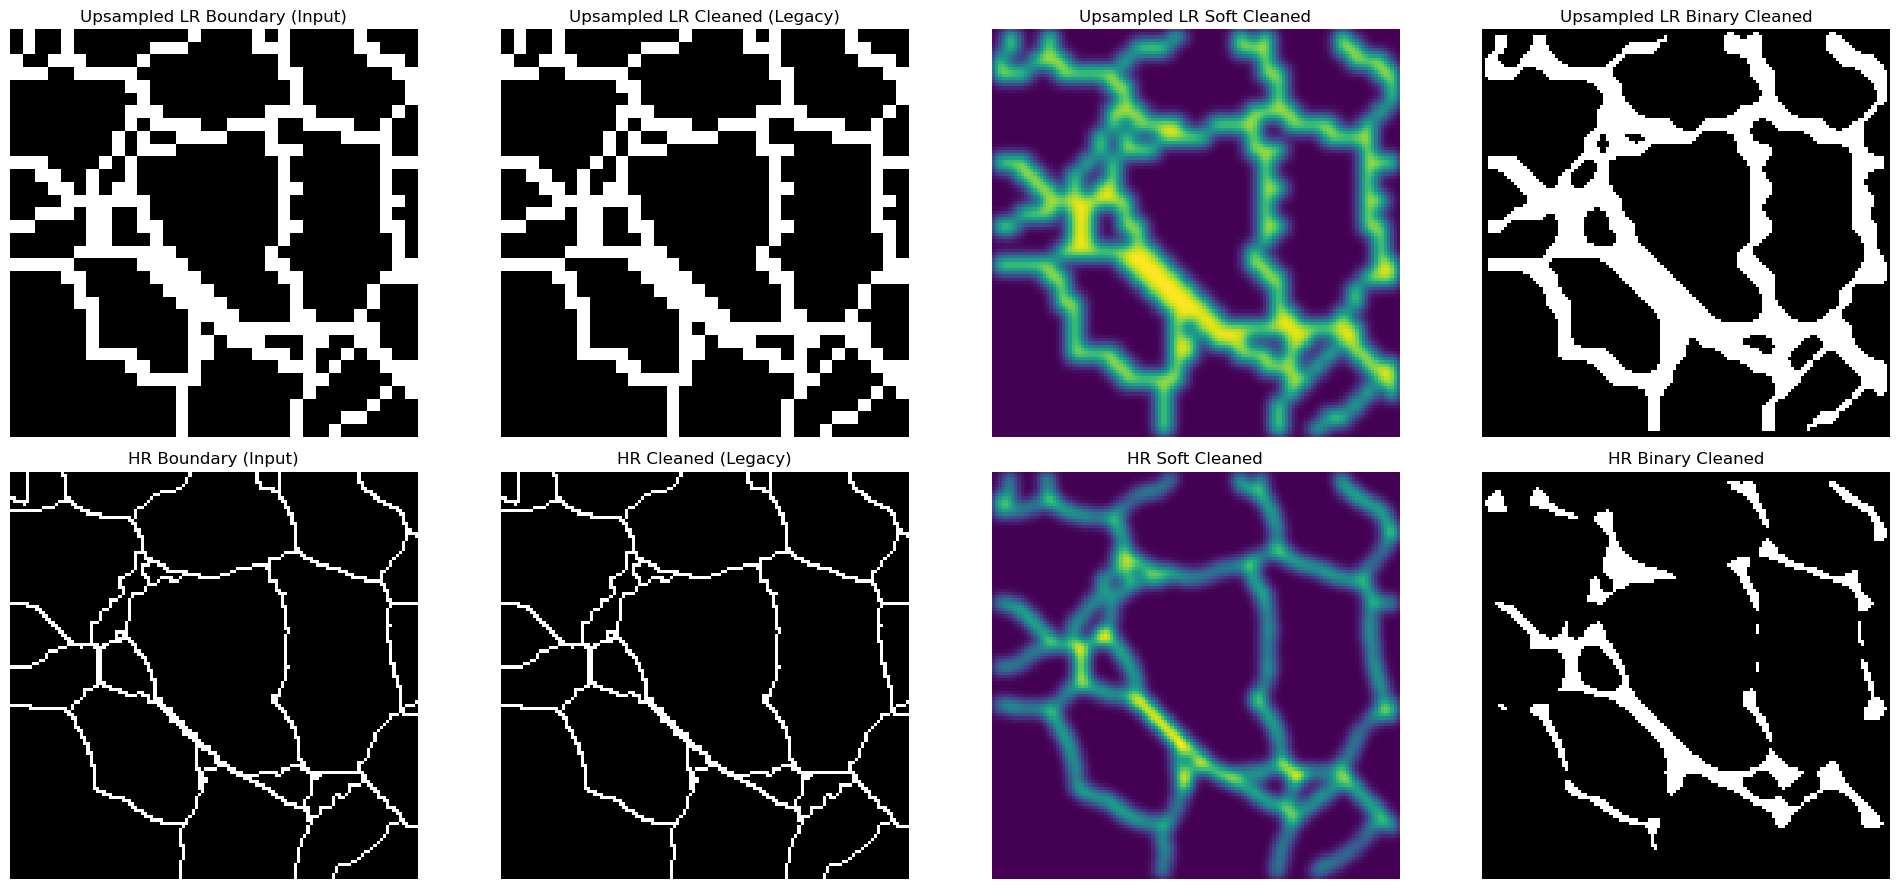

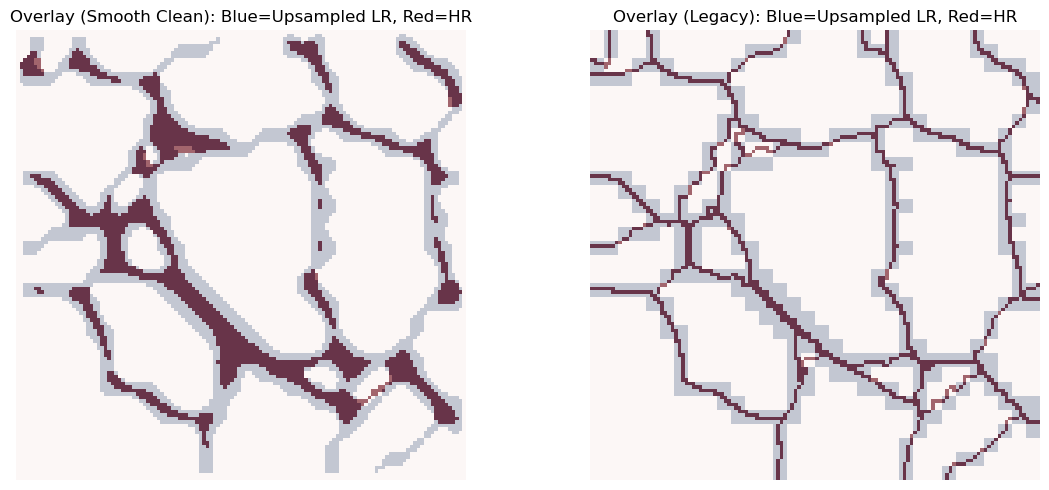

Saved: /data/home/umang/Materials/Reynolds-QSR_4x1/outputs/in718_train_sample225_slerp_final_segment_grains/boundary_cleaning_lrup_vs_hr.png
Saved: /data/home/umang/Materials/Reynolds-QSR_4x1/outputs/in718_train_sample225_slerp_final_segment_grains/boundary_cleaning_overlay_lrup_hr.png


In [11]:
# NEW: Plot inputs vs outputs of boundary cleaning
fig, ax = plt.subplots(2, 4, figsize=(20, 9))

ax[0, 0].imshow(boundary_lr_up.detach().cpu().numpy(), cmap="gray")
ax[0, 0].set_title("Upsampled LR Boundary (Input)")
ax[0, 0].axis("off")

ax[0, 1].imshow(boundary_lr_up_clean_legacy.detach().cpu().numpy(), cmap="gray")
ax[0, 1].set_title("Upsampled LR Cleaned (Legacy)")
ax[0, 1].axis("off")

ax[0, 2].imshow(boundary_lr_up_soft_clean.detach().cpu().numpy(), cmap="viridis")
ax[0, 2].set_title("Upsampled LR Soft Cleaned")
ax[0, 2].axis("off")

ax[0, 3].imshow(boundary_lr_up_clean.detach().cpu().numpy(), cmap="gray")
ax[0, 3].set_title("Upsampled LR Binary Cleaned")
ax[0, 3].axis("off")

ax[1, 0].imshow(boundary_hr.detach().cpu().numpy(), cmap="gray")
ax[1, 0].set_title("HR Boundary (Input)")
ax[1, 0].axis("off")

ax[1, 1].imshow(boundary_hr_clean_legacy.detach().cpu().numpy(), cmap="gray")
ax[1, 1].set_title("HR Cleaned (Legacy)")
ax[1, 1].axis("off")

ax[1, 2].imshow(boundary_hr_soft_clean.detach().cpu().numpy(), cmap="viridis")
ax[1, 2].set_title("HR Soft Cleaned")
ax[1, 2].axis("off")

ax[1, 3].imshow(boundary_hr_clean.detach().cpu().numpy(), cmap="gray")
ax[1, 3].set_title("HR Binary Cleaned")
ax[1, 3].axis("off")

plt.tight_layout()
plt.savefig(out_dir / "boundary_cleaning_lrup_vs_hr.png", dpi=220, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(boundary_lr_up_clean.detach().cpu().numpy(), cmap="Blues", alpha=0.6)
ax[0].imshow(boundary_hr_clean.detach().cpu().numpy(), cmap="Reds", alpha=0.6)
ax[0].set_title("Overlay (Smooth Clean): Blue=Upsampled LR, Red=HR")
ax[0].axis("off")

ax[1].imshow(boundary_lr_up_clean_legacy.detach().cpu().numpy(), cmap="Blues", alpha=0.6)
ax[1].imshow(boundary_hr_clean_legacy.detach().cpu().numpy(), cmap="Reds", alpha=0.6)
ax[1].set_title("Overlay (Legacy): Blue=Upsampled LR, Red=HR")
ax[1].axis("off")

plt.tight_layout()
plt.savefig(out_dir / "boundary_cleaning_overlay_lrup_hr.png", dpi=220, bbox_inches="tight")
plt.show()

print("Saved:", out_dir / "boundary_cleaning_lrup_vs_hr.png")
print("Saved:", out_dir / "boundary_cleaning_overlay_lrup_hr.png")


Saved boundary case map -> /data/home/umang/Materials/Reynolds-QSR_4x1/outputs/in718_train_sample225_slerp_final_segment_grains/pipeline_boundary_case_map.png
[SymBilinearSlerpUpsample] seam crossings: 3720/32768 (11.353%)


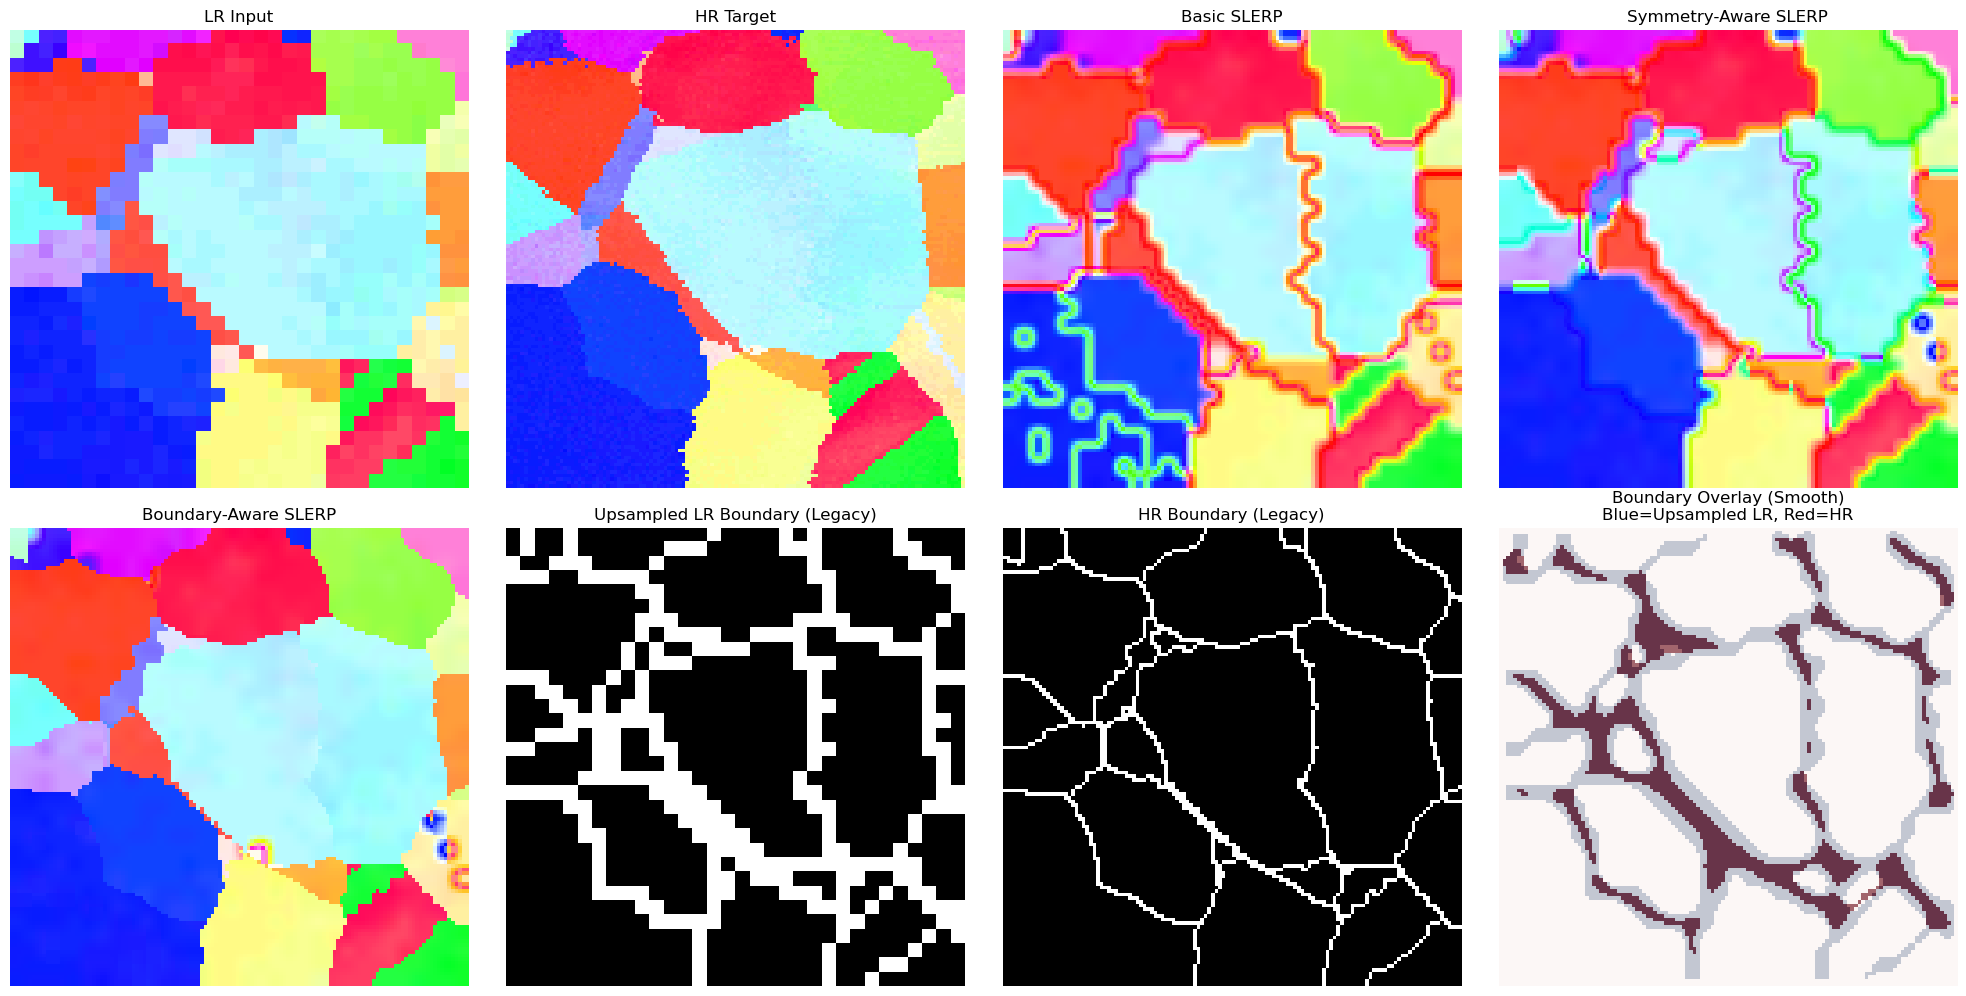

Pipeline grains: 38
Saved: /data/home/umang/Materials/Reynolds-QSR_4x1/outputs/in718_train_sample225_slerp_final_segment_grains/pipeline_boundary_case_map.png
Saved: /data/home/umang/Materials/Reynolds-QSR_4x1/outputs/in718_train_sample225_slerp_final_segment_grains/pipeline_full_block_summary.png


In [12]:
# PIPELINE BLOCK: Full boundary-aware flow
# Runs the complete boundary-aware pipeline in one place.
required = [
    "q_lr", "q_hr_gt", "sym_ops", "scale", "device", "out_dir",
    "segment_grains_graph", "cleanup_small_grains_cuda",
    "build_smooth_hr_labels", "build_sdf",
    "analyze_boundary_cases", "boundary_aware_sym_slerp_upsample",
    "BasicBilinearSlerpUpsample", "SymBilinearSlerpUpsample",
    "qnorm", "render_ipf_rgb", "to_hwc_np",
]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(f"Run setup/model cells first. Missing: {missing}")

# 1) LR segmentation + cleanup
labels_np_all, n_grains_all = segment_grains_graph(q_lr.cpu(), sym_ops.cpu(), thr_deg=3.0)
labels_lr_all = torch.from_numpy(labels_np_all).long().to(device)
labels_lr_all = cleanup_small_grains_cuda(
    labels_lr_all,
    q_lr,
    sym_ops,
    min_pixels=3,
    max_iter=1,
)

# 2) HR labels + SDF from LR labels
labels_hr_all = build_smooth_hr_labels(labels_lr_all, scale=scale, sdf_shift=0.7)
sdf_hr_all = build_sdf(labels_lr_all, scale=scale)

# 3) Boundary case analysis
same_mask_all, w_all, case_map_all = analyze_boundary_cases(
    labels_lr_all,
    labels_hr_all,
    scale=scale,
    out_png=str(out_dir / "pipeline_boundary_case_map.png"),
)

# 4) Basic / symmetry-aware / boundary-aware upsampling
basic_up_all = BasicBilinearSlerpUpsample(scale_factor=scale).to(device)
sym_up_all = SymBilinearSlerpUpsample(
    scale_factor=scale,
    seam_threshold_deg=5.0,
    device=str(device),
    dtype=q_lr.dtype,
).to(device)

with torch.inference_mode():
    q_hr_basic_all = qnorm(basic_up_all(q_lr))
    q_hr_sym_all = qnorm(sym_up_all(q_lr))

q_hr_boundary_all = boundary_aware_sym_slerp_upsample(
    q_lr=q_lr,
    labels_lr=labels_lr_all,
    labels_hr=labels_hr_all,
    sym_ops=sym_ops,
    scale=scale,
    same_mask_flat=same_mask_all,
    w_flat=w_all,
    case_map=case_map_all,
)
q_hr_boundary_all = qnorm(q_hr_boundary_all)

# 5) Boundary extraction (LR upsampled + HR)
def _extract_boundary_mask(labels: torch.Tensor) -> torch.Tensor:
    b = torch.zeros_like(labels, dtype=torch.bool)
    b[:, 1:] |= labels[:, 1:] != labels[:, :-1]
    b[1:, :] |= labels[1:, :] != labels[:-1, :]
    return b

boundary_lr_all = _extract_boundary_mask(labels_lr_all)
boundary_hr_all = _extract_boundary_mask(labels_hr_all)
boundary_lr_up_all = F.interpolate(
    boundary_lr_all.float().unsqueeze(0).unsqueeze(0),
    size=labels_hr_all.shape,
    mode="nearest",
)[0, 0].bool()

# 6) Optional boundary cleaning (legacy + smooth)
if "clean_boundary_map" in globals():
    _, boundary_lr_up_clean_legacy_all = clean_boundary_map(boundary_lr_up_all, mode="legacy")
    _, boundary_hr_clean_legacy_all = clean_boundary_map(boundary_hr_all, mode="legacy")
    _, boundary_lr_up_clean_all = clean_boundary_map(
        boundary_lr_up_all, mode="smooth_threshold", iters=4, sigma=1.2, threshold=0.45
    )
    _, boundary_hr_clean_all = clean_boundary_map(
        boundary_hr_all, mode="smooth_threshold", iters=4, sigma=1.2, threshold=0.45
    )
else:
    boundary_lr_up_clean_legacy_all = boundary_lr_up_all
    boundary_hr_clean_legacy_all = boundary_hr_all
    boundary_lr_up_clean_all = boundary_lr_up_all
    boundary_hr_clean_all = boundary_hr_all

# 7) Save one compact final panel for the full pipeline
rgb_lr_all = render_ipf_rgb(to_hwc_np(q_lr), sym_class, ref_dir="Z")
rgb_hr_gt_all = render_ipf_rgb(to_hwc_np(q_hr_gt), sym_class, ref_dir="Z")
rgb_basic_all = render_ipf_rgb(to_hwc_np(q_hr_basic_all), sym_class, ref_dir="Z")
rgb_sym_all = render_ipf_rgb(to_hwc_np(q_hr_sym_all), sym_class, ref_dir="Z")
rgb_boundary_all = render_ipf_rgb(to_hwc_np(q_hr_boundary_all), sym_class, ref_dir="Z")

fig, ax = plt.subplots(2, 4, figsize=(20, 10))
ax[0, 0].imshow(rgb_lr_all); ax[0, 0].set_title("LR Input"); ax[0, 0].axis("off")
ax[0, 1].imshow(rgb_hr_gt_all); ax[0, 1].set_title("HR Target"); ax[0, 1].axis("off")
ax[0, 2].imshow(rgb_basic_all); ax[0, 2].set_title("Basic SLERP"); ax[0, 2].axis("off")
ax[0, 3].imshow(rgb_sym_all); ax[0, 3].set_title("Symmetry-Aware SLERP"); ax[0, 3].axis("off")

ax[1, 0].imshow(rgb_boundary_all); ax[1, 0].set_title("Boundary-Aware SLERP"); ax[1, 0].axis("off")
ax[1, 1].imshow(boundary_lr_up_clean_legacy_all.detach().cpu().numpy(), cmap="gray"); ax[1, 1].set_title("Upsampled LR Boundary (Legacy)"); ax[1, 1].axis("off")
ax[1, 2].imshow(boundary_hr_clean_legacy_all.detach().cpu().numpy(), cmap="gray"); ax[1, 2].set_title("HR Boundary (Legacy)"); ax[1, 2].axis("off")
ax[1, 3].imshow(boundary_lr_up_clean_all.detach().cpu().numpy(), cmap="Blues", alpha=0.6)
ax[1, 3].imshow(boundary_hr_clean_all.detach().cpu().numpy(), cmap="Reds", alpha=0.6)
ax[1, 3].set_title("Boundary Overlay (Smooth)\nBlue=Upsampled LR, Red=HR")
ax[1, 3].axis("off")

plt.tight_layout()
plt.savefig(out_dir / "pipeline_full_block_summary.png", dpi=220, bbox_inches="tight")
plt.show()

print("Pipeline grains:", n_grains_all)
print("Saved:", out_dir / "pipeline_boundary_case_map.png")
print("Saved:", out_dir / "pipeline_full_block_summary.png")


In [ ]:
# BOUNDARY-ONLY BLOCK: Step-by-step boundary pipeline
# Clean, end-to-end boundary pipeline using LR 1-pixel boundary as the driving input.
required = [
    "q_lr", "sym_ops", "scale", "device", "out_dir",
    "segment_grains_graph", "cleanup_small_grains_cuda",
]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(f"Run setup cells first. Missing: {missing}")

@torch.no_grad()
def thin_boundary_from_labels(labels_2d: torch.Tensor) -> torch.Tensor:
    """One-sided 1-pixel boundary from integer labels."""
    if labels_2d.ndim != 2:
        raise ValueError(f"Expected (H,W), got {tuple(labels_2d.shape)}")
    b = torch.zeros_like(labels_2d, dtype=torch.bool)
    b[:, 1:] |= labels_2d[:, 1:] != labels_2d[:, :-1]
    b[1:, :] |= labels_2d[1:, :] != labels_2d[:-1, :]
    return b

@torch.no_grad()
def smooth_boundary_to_sdf(boundary_lr_1px: torch.Tensor, scale: int, sigma: float = 2.0, iters: int = 12) -> torch.Tensor:
    """LR 1px boundary -> smooth HR boundary field (SDF-like)."""
    if boundary_lr_1px.ndim != 2:
        raise ValueError(f"Expected (H,W), got {tuple(boundary_lr_1px.shape)}")
    gb_lr = boundary_lr_1px.float()
    H, W = gb_lr.shape
    Hh, Wh = H * int(scale), W * int(scale)

    gb_hr = F.interpolate(gb_lr[None, None], size=(Hh, Wh), mode="nearest")[0, 0]

    box = torch.ones((1, 1, 3, 3), device=gb_lr.device, dtype=gb_lr.dtype) / 9.0
    sm = gb_hr.clone()
    for _ in range(int(iters)):
        sm = F.conv2d(sm[None, None], box, padding=1)[0, 0]

    size = int(6 * sigma + 1)
    if size % 2 == 0:
        size += 1
    half = size // 2
    coords = torch.arange(size, device=gb_lr.device, dtype=gb_lr.dtype) - half
    g1 = torch.exp(-(coords ** 2) / (2 * sigma * sigma))
    g1 = g1 / g1.sum()
    g2 = torch.outer(g1, g1)[None, None]

    sdf_hr = F.conv2d(sm[None, None], g2, padding=half)[0, 0]
    sdf_hr = sdf_hr / (sdf_hr.max() + 1e-8)
    return sdf_hr

@torch.no_grad()
def remap_lr_labels_to_hr(labels_lr: torch.Tensor, sdf_hr: torch.Tensor, scale: int, sdf_shift: float = 0.7) -> torch.Tensor:
    """Generate HR labels by normal-shift remap of LR labels using a provided HR field."""
    H, W = labels_lr.shape
    Hh, Wh = sdf_hr.shape
    if Hh != H * int(scale) or Wh != W * int(scale):
        raise ValueError("sdf_hr shape incompatible with labels_lr and scale")

    dy = torch.zeros_like(sdf_hr)
    dx = torch.zeros_like(sdf_hr)
    dy[1:-1, :] = 0.5 * (sdf_hr[2:, :] - sdf_hr[:-2, :])
    dy[0, :] = sdf_hr[1, :] - sdf_hr[0, :]
    dy[-1, :] = sdf_hr[-1, :] - sdf_hr[-2, :]
    dx[:, 1:-1] = 0.5 * (sdf_hr[:, 2:] - sdf_hr[:, :-2])
    dx[:, 0] = sdf_hr[:, 1] - sdf_hr[:, 0]
    dx[:, -1] = sdf_hr[:, -1] - sdf_hr[:, -2]

    norm = torch.sqrt(dx * dx + dy * dy + 1e-12)
    nx = dx / norm
    ny = dy / norm

    yy = torch.arange(Hh, device=sdf_hr.device, dtype=sdf_hr.dtype)
    xx = torch.arange(Wh, device=sdf_hr.device, dtype=sdf_hr.dtype)
    y_base = (yy + 0.5) / int(scale) - 0.5
    x_base = (xx + 0.5) / int(scale) - 0.5
    y_grid, x_grid = torch.meshgrid(y_base, x_base, indexing="ij")

    y_shift = y_grid - float(sdf_shift) * ny
    x_shift = x_grid - float(sdf_shift) * nx
    y_nn = torch.round(y_shift).clamp(0, H - 1).long()
    x_nn = torch.round(x_shift).clamp(0, W - 1).long()
    return labels_lr[y_nn, x_nn].long()

# 1) LR segmentation + cleanup
labels_np_clean, n_grains = segment_grains_graph(q_lr.cpu(), sym_ops.cpu(), thr_deg=3.0)
labels_lr_clean = torch.from_numpy(labels_np_clean).long().to(device)
labels_lr_clean = cleanup_small_grains_cuda(
    labels_lr_clean, q_lr, sym_ops, min_pixels=3, max_iter=1
)

# 2) LR 1-pixel boundary
boundary_lr_1px = thin_boundary_from_labels(labels_lr_clean)

# 3) Upsampled LR labels and 1-pixel boundary (comparison baseline)
Hh, Wh = labels_lr_clean.shape[0] * int(scale), labels_lr_clean.shape[1] * int(scale)
labels_lr_up_nn = F.interpolate(labels_lr_clean.float()[None, None], size=(Hh, Wh), mode="nearest")[0, 0].round().long()
boundary_lr_up_1px = thin_boundary_from_labels(labels_lr_up_nn)

# 4) Build HR field from LR 1px boundary
sdf_hr_from_lr_boundary = smooth_boundary_to_sdf(boundary_lr_1px, scale=int(scale), sigma=2.0, iters=12)

# 5) Build HR labels from LR labels + HR field
labels_hr_from_lr_boundary = remap_lr_labels_to_hr(
    labels_lr_clean, sdf_hr_from_lr_boundary, scale=int(scale), sdf_shift=0.7
)

# 6) Final HR 1-pixel boundary
boundary_hr_1px = thin_boundary_from_labels(labels_hr_from_lr_boundary)

# 7) Optional visual cleaning
if "clean_boundary_map" in globals():
    _, boundary_lr_up_clean = clean_boundary_map(boundary_lr_up_1px, mode="smooth_threshold", iters=4, sigma=1.2, threshold=0.45)
    _, boundary_hr_clean = clean_boundary_map(boundary_hr_1px, mode="smooth_threshold", iters=4, sigma=1.2, threshold=0.45)
else:
    boundary_lr_up_clean = boundary_lr_up_1px
    boundary_hr_clean = boundary_hr_1px

# 8) Plot clean step-by-step outputs
fig, ax = plt.subplots(2, 4, figsize=(20, 10))
ax[0, 0].imshow(labels_lr_clean.detach().cpu().numpy(), cmap="tab20"); ax[0, 0].set_title("LR Labels (clean)"); ax[0, 0].axis("off")
ax[0, 1].imshow(boundary_lr_1px.detach().cpu().numpy(), cmap="gray"); ax[0, 1].set_title("LR Boundary (1px)"); ax[0, 1].axis("off")
ax[0, 2].imshow(labels_lr_up_nn.detach().cpu().numpy(), cmap="tab20"); ax[0, 2].set_title("Upsampled LR Labels (NN)"); ax[0, 2].axis("off")
ax[0, 3].imshow(boundary_lr_up_1px.detach().cpu().numpy(), cmap="gray"); ax[0, 3].set_title("Upsampled LR Boundary (1px)"); ax[0, 3].axis("off")

im = ax[1, 0].imshow(sdf_hr_from_lr_boundary.detach().cpu().numpy(), cmap="viridis"); ax[1, 0].set_title("HR Field from LR 1px Boundary"); ax[1, 0].axis("off"); fig.colorbar(im, ax=ax[1, 0], fraction=0.046, pad=0.04)
ax[1, 1].imshow(labels_hr_from_lr_boundary.detach().cpu().numpy(), cmap="tab20"); ax[1, 1].set_title("HR Labels (remapped)"); ax[1, 1].axis("off")
ax[1, 2].imshow(boundary_hr_1px.detach().cpu().numpy(), cmap="gray"); ax[1, 2].set_title("Final HR Boundary (1px)"); ax[1, 2].axis("off")
ax[1, 3].imshow(boundary_lr_up_clean.detach().cpu().numpy(), cmap="Blues", alpha=0.6); ax[1, 3].imshow(boundary_hr_clean.detach().cpu().numpy(), cmap="Reds", alpha=0.6); ax[1, 3].set_title("Overlay\nBlue=Upsampled LR, Red=Final HR"); ax[1, 3].axis("off")

plt.tight_layout()
plt.savefig(out_dir / "boundary_only_step_by_step.png", dpi=220, bbox_inches="tight")
plt.show()

print("Boundary-only pipeline complete")
print("grains (initial segmentation):", n_grains)
print("LR labels:", tuple(labels_lr_clean.shape), "HR labels:", tuple(labels_hr_from_lr_boundary.shape))
print("LR boundary pixels:", int(boundary_lr_1px.sum().item()))
print("Upsampled LR boundary pixels:", int(boundary_lr_up_1px.sum().item()))
print("Final HR boundary pixels:", int(boundary_hr_1px.sum().item()))
print("Saved:", out_dir / "boundary_only_step_by_step.png")
